# Предсказание результата матча Dota 2

## Разведочный анализ данных и подготовка данных

### Общая информация
В данном ноутбуке смотрю на сырые данные, они находятся в папке `data/raw`. Данные после преобразований будут находиться в папке `data/clean`.

In [237]:
import category_encoders as ce
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from typing import Iterable
from pathlib import Path

%config InlineBackend.figure_format = 'retina' 
sns.set_theme(style='darkgrid', palette='deep', context='talk') 
plt.rcParams['figure.figsize'] = 16, 7 

plt.rcParams['font.size'] = 16 
plt.rcParams['savefig.format'] = 'pdf'
RadiantDire = {
    True: "#9DBE86",
    False: "#8F4343"
}

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / ".git").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

In [238]:
raw_data_path =  PROJECT_ROOT / "data" /  "raw"
matches_df_train = pd.read_csv(raw_data_path / "matches_df_train.csv")
matches_df_test = pd.read_csv(raw_data_path / "matches_df_test.csv")

matches_df_train = matches_df_train.set_index('match_id')
matches_df_test = matches_df_test.set_index('match_id')

matches_df_train['dataset'] = 'Train'
matches_df_test['dataset'] = 'Test'
matches_df_train['date'] = pd.to_datetime(matches_df_train['date'])
matches_df_test['date'] = pd.to_datetime(matches_df_test['date'])

df_matches_all = pd.concat([matches_df_train, matches_df_test])

df_matches_all.head()

,date,region,game_mode,duration,radiant_win,avg_mmr,dataset
match_id,,,,,,,
1,2024-02-12,Europe West,4,2625.0,False,3519.7,Train
2,2024-04-08,South Africa,2,7526.0,True,2330.9,Train
3,2024-06-16,SE Asia,1,2831.0,True,1579.6,Train
4,2024-09-16,Middle East,22,1438.0,False,NaN,Train
5,2024-03-31,South Africa,22,2051.0,True,NaN,Train


### Посмотрим на рапределение целевой переменной

Хочется посмотреть общее распределение, распределение в зависимости от региона и других признаков.

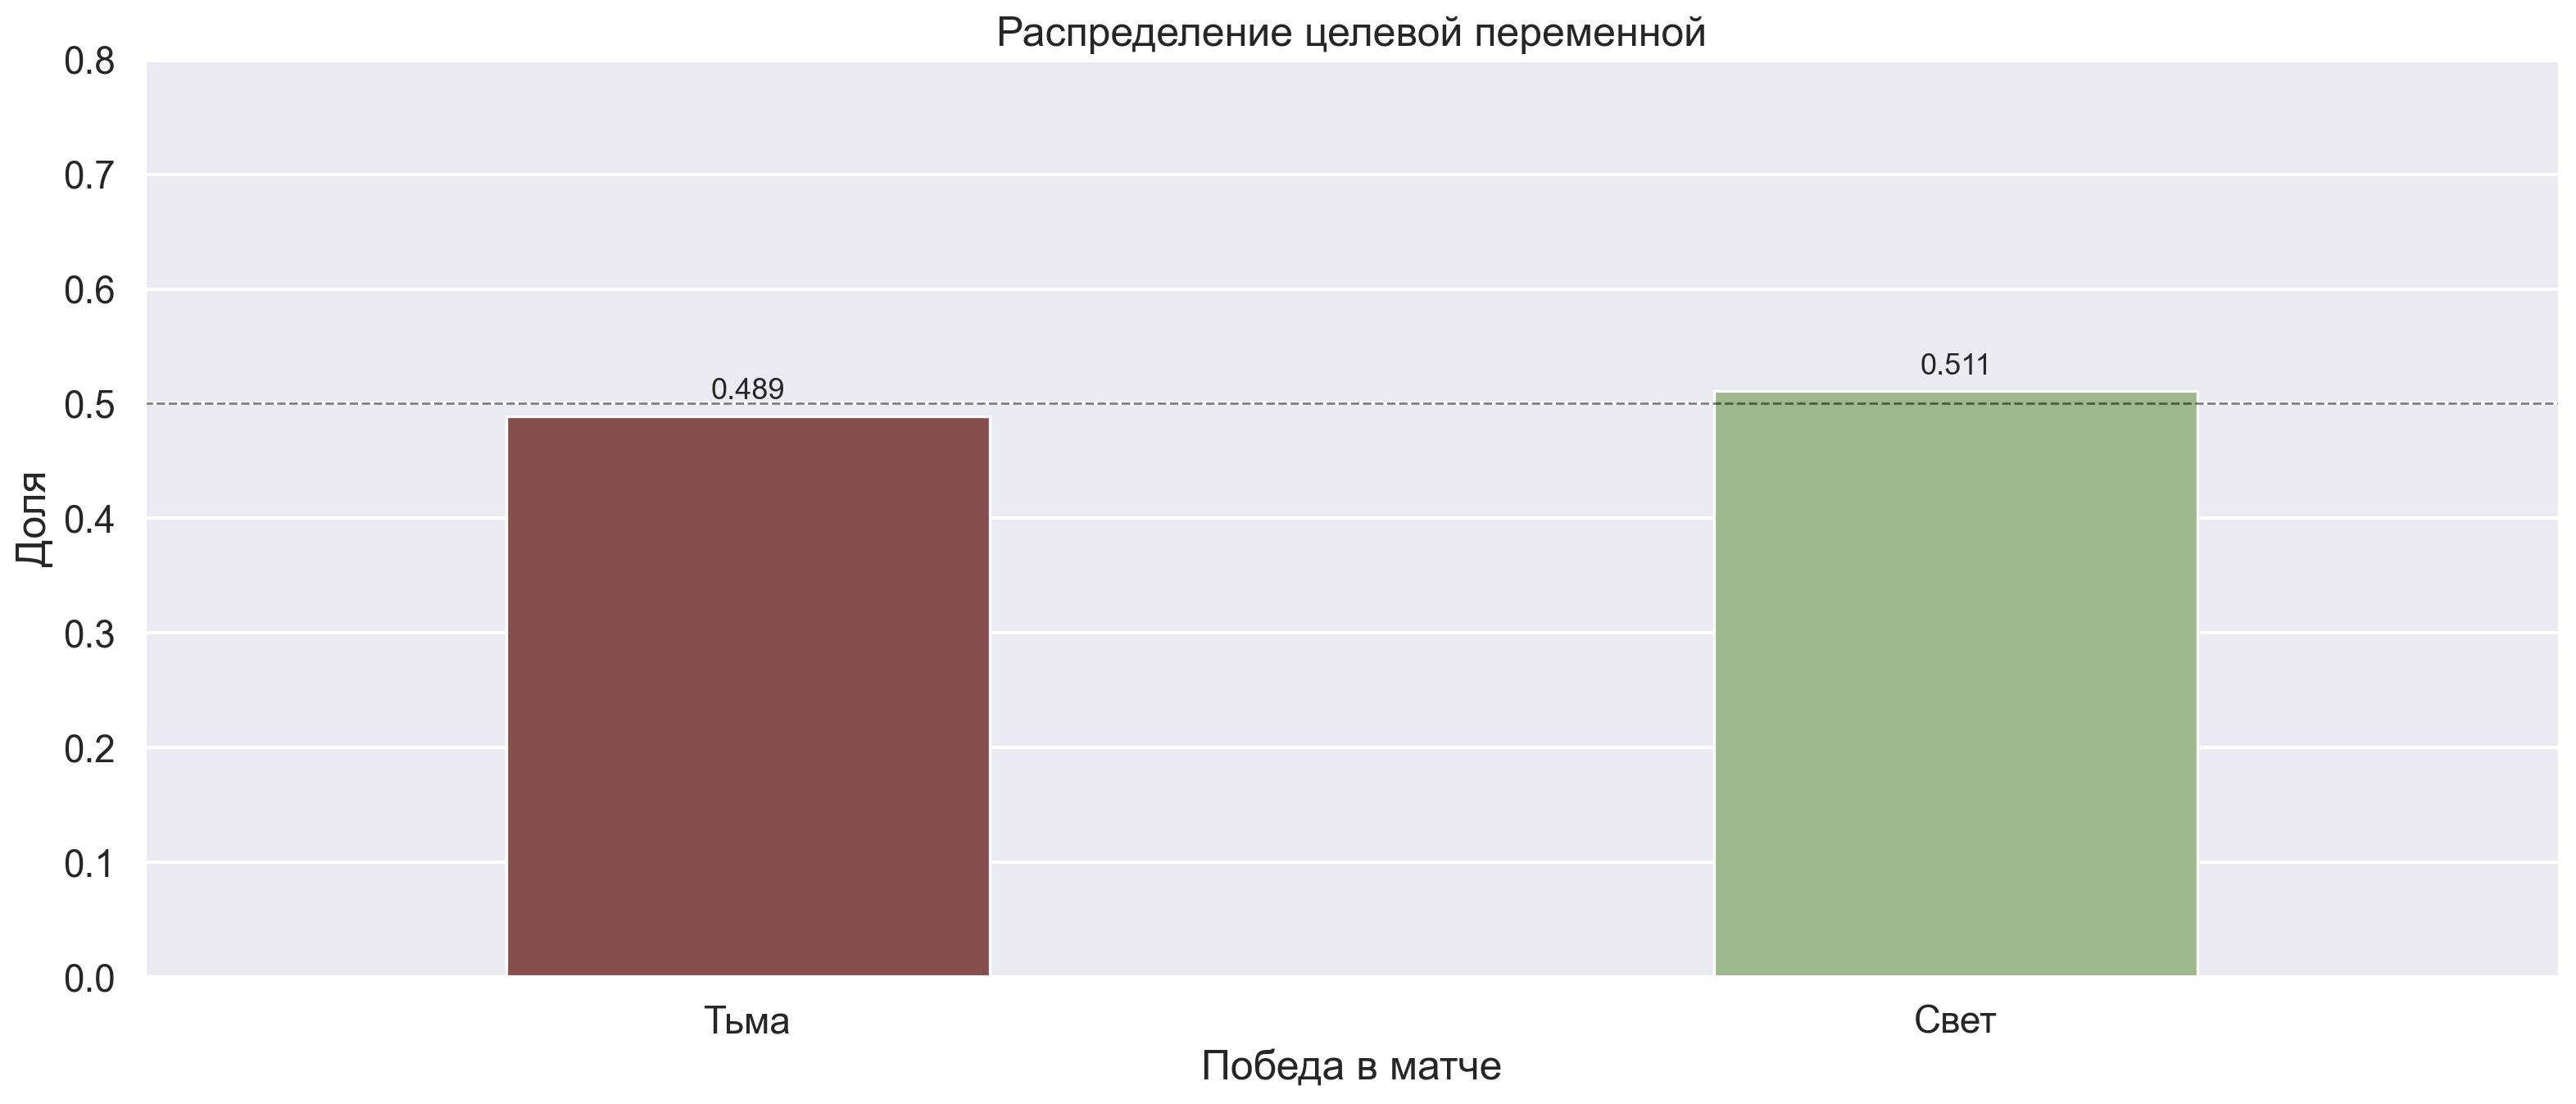

In [239]:
fig, ax = plt.subplots()
plt.title("Распределение целевой переменной", fontsize=18)
sns.countplot(data=matches_df_train, x='radiant_win', stat='proportion', legend=False,
              hue='radiant_win', palette=RadiantDire, width=0.4, edgecolor='white', linewidth=1.2)

ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylim(0, 0.8)
ax.set_xticks([False, True])
ax.set_xticklabels(['Тьма', 'Свет'])
ax.set_xlabel("Победа в матче")
ax.set_ylabel("Доля")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=13, padding=5)

plt.tight_layout()
plt.show()

#### Регионы

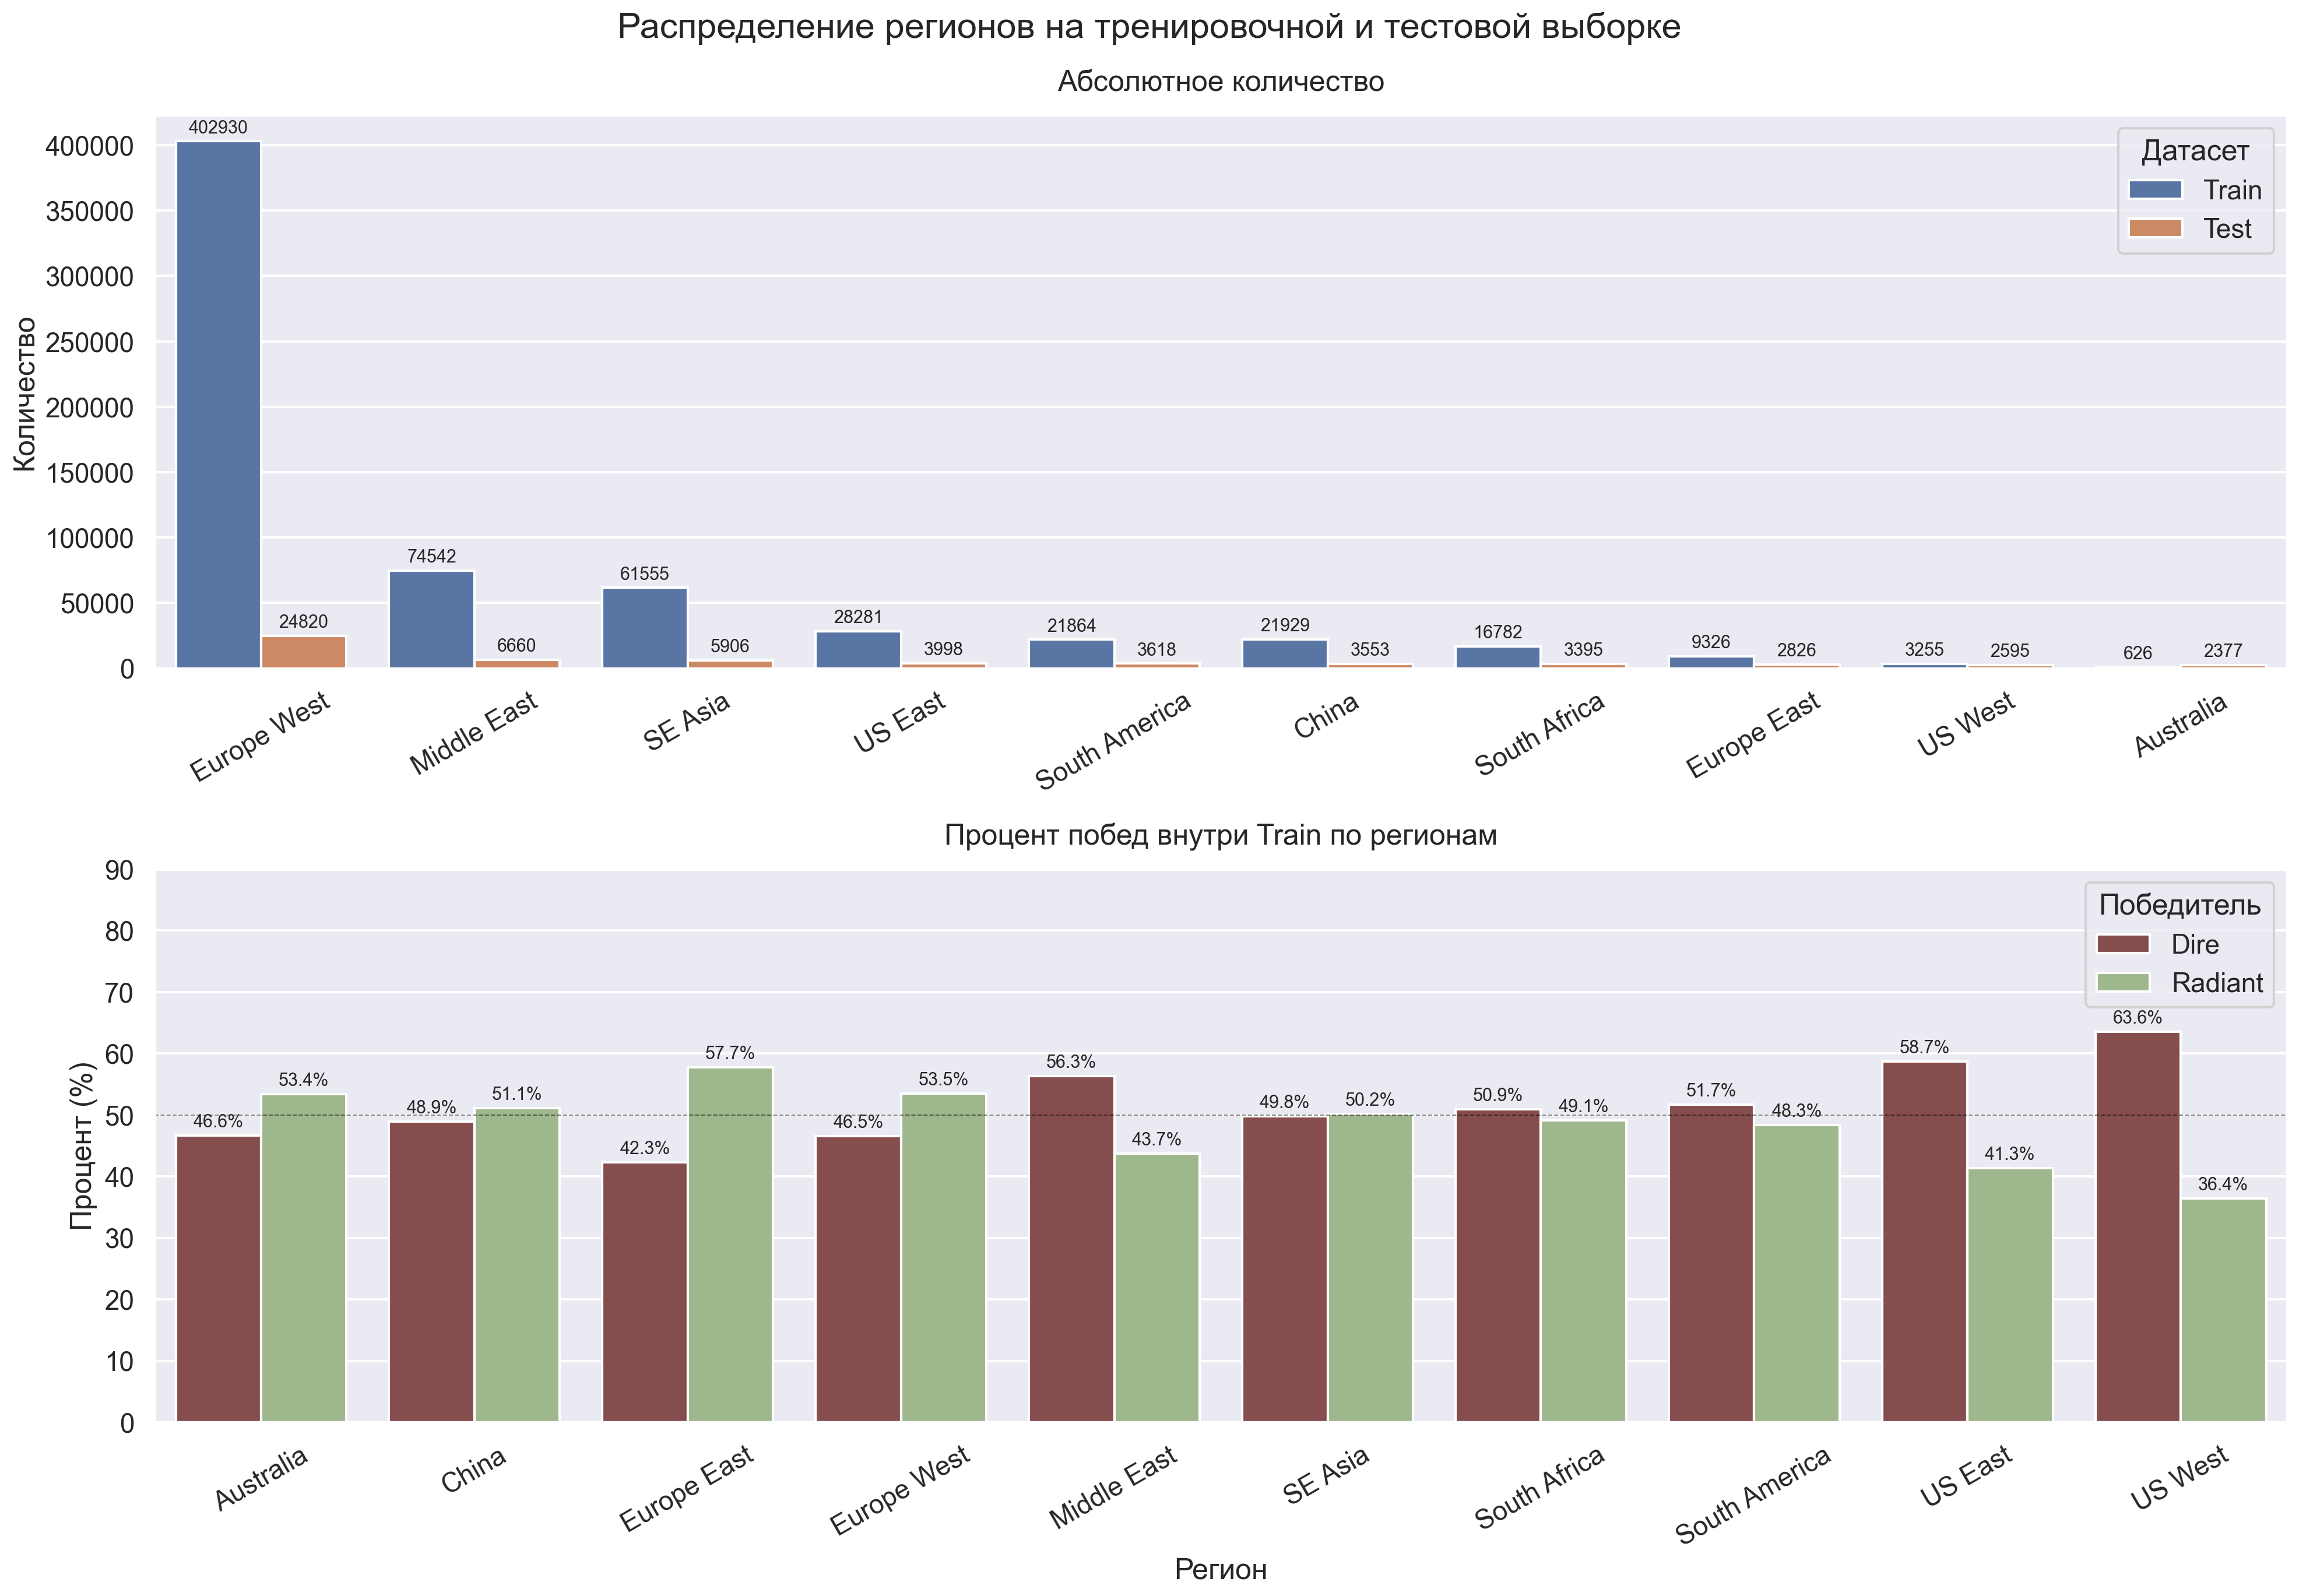

In [240]:
# Зафиксирую порядок для удобства отображения
order = (df_matches_all['region'].value_counts().index)

fig, ax = plt.subplots(2, 1, figsize=(20, 14))
plt.suptitle("Распределение регионов на тренировочной и тестовой выборке", fontsize=22)

sns.countplot(data=df_matches_all, x='region', hue='dataset', order=order, ax=ax[0])

region_win_rates = matches_df_train.groupby('region')['radiant_win'].value_counts(normalize=True).reset_index(name='proportion')
region_win_rates['proportion'] = region_win_rates['proportion'] * 100
sns.barplot(data=region_win_rates, x='region', y='proportion', hue='radiant_win', palette=RadiantDire, ax=ax[1])
ax[1].axhline(y=50, color='black', linestyle='--', linewidth=0.7, alpha=0.5)

ax[0].set_title("Абсолютное количество", pad=15)
ax[0].set_xlabel("")
ax[0].set_ylabel("Количество")
ax[0].legend(title = "Датасет")
for container in ax[0].containers:
    ax[0].bar_label(container, fontsize=11, padding=3)

ax[1].set_title("Процент побед внутри Train по регионам", pad=15)
ax[1].set_xlabel("Регион")
ax[1].set_ylabel("Процент (%)")
ax[1].set_ylim((0, 90))
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%.1f%%", fontsize=11, padding=3)
    
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(handles,["Dire", "Radiant"],title="Победитель")

ax[0].tick_params(axis='x', rotation=30)
ax[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### Даты

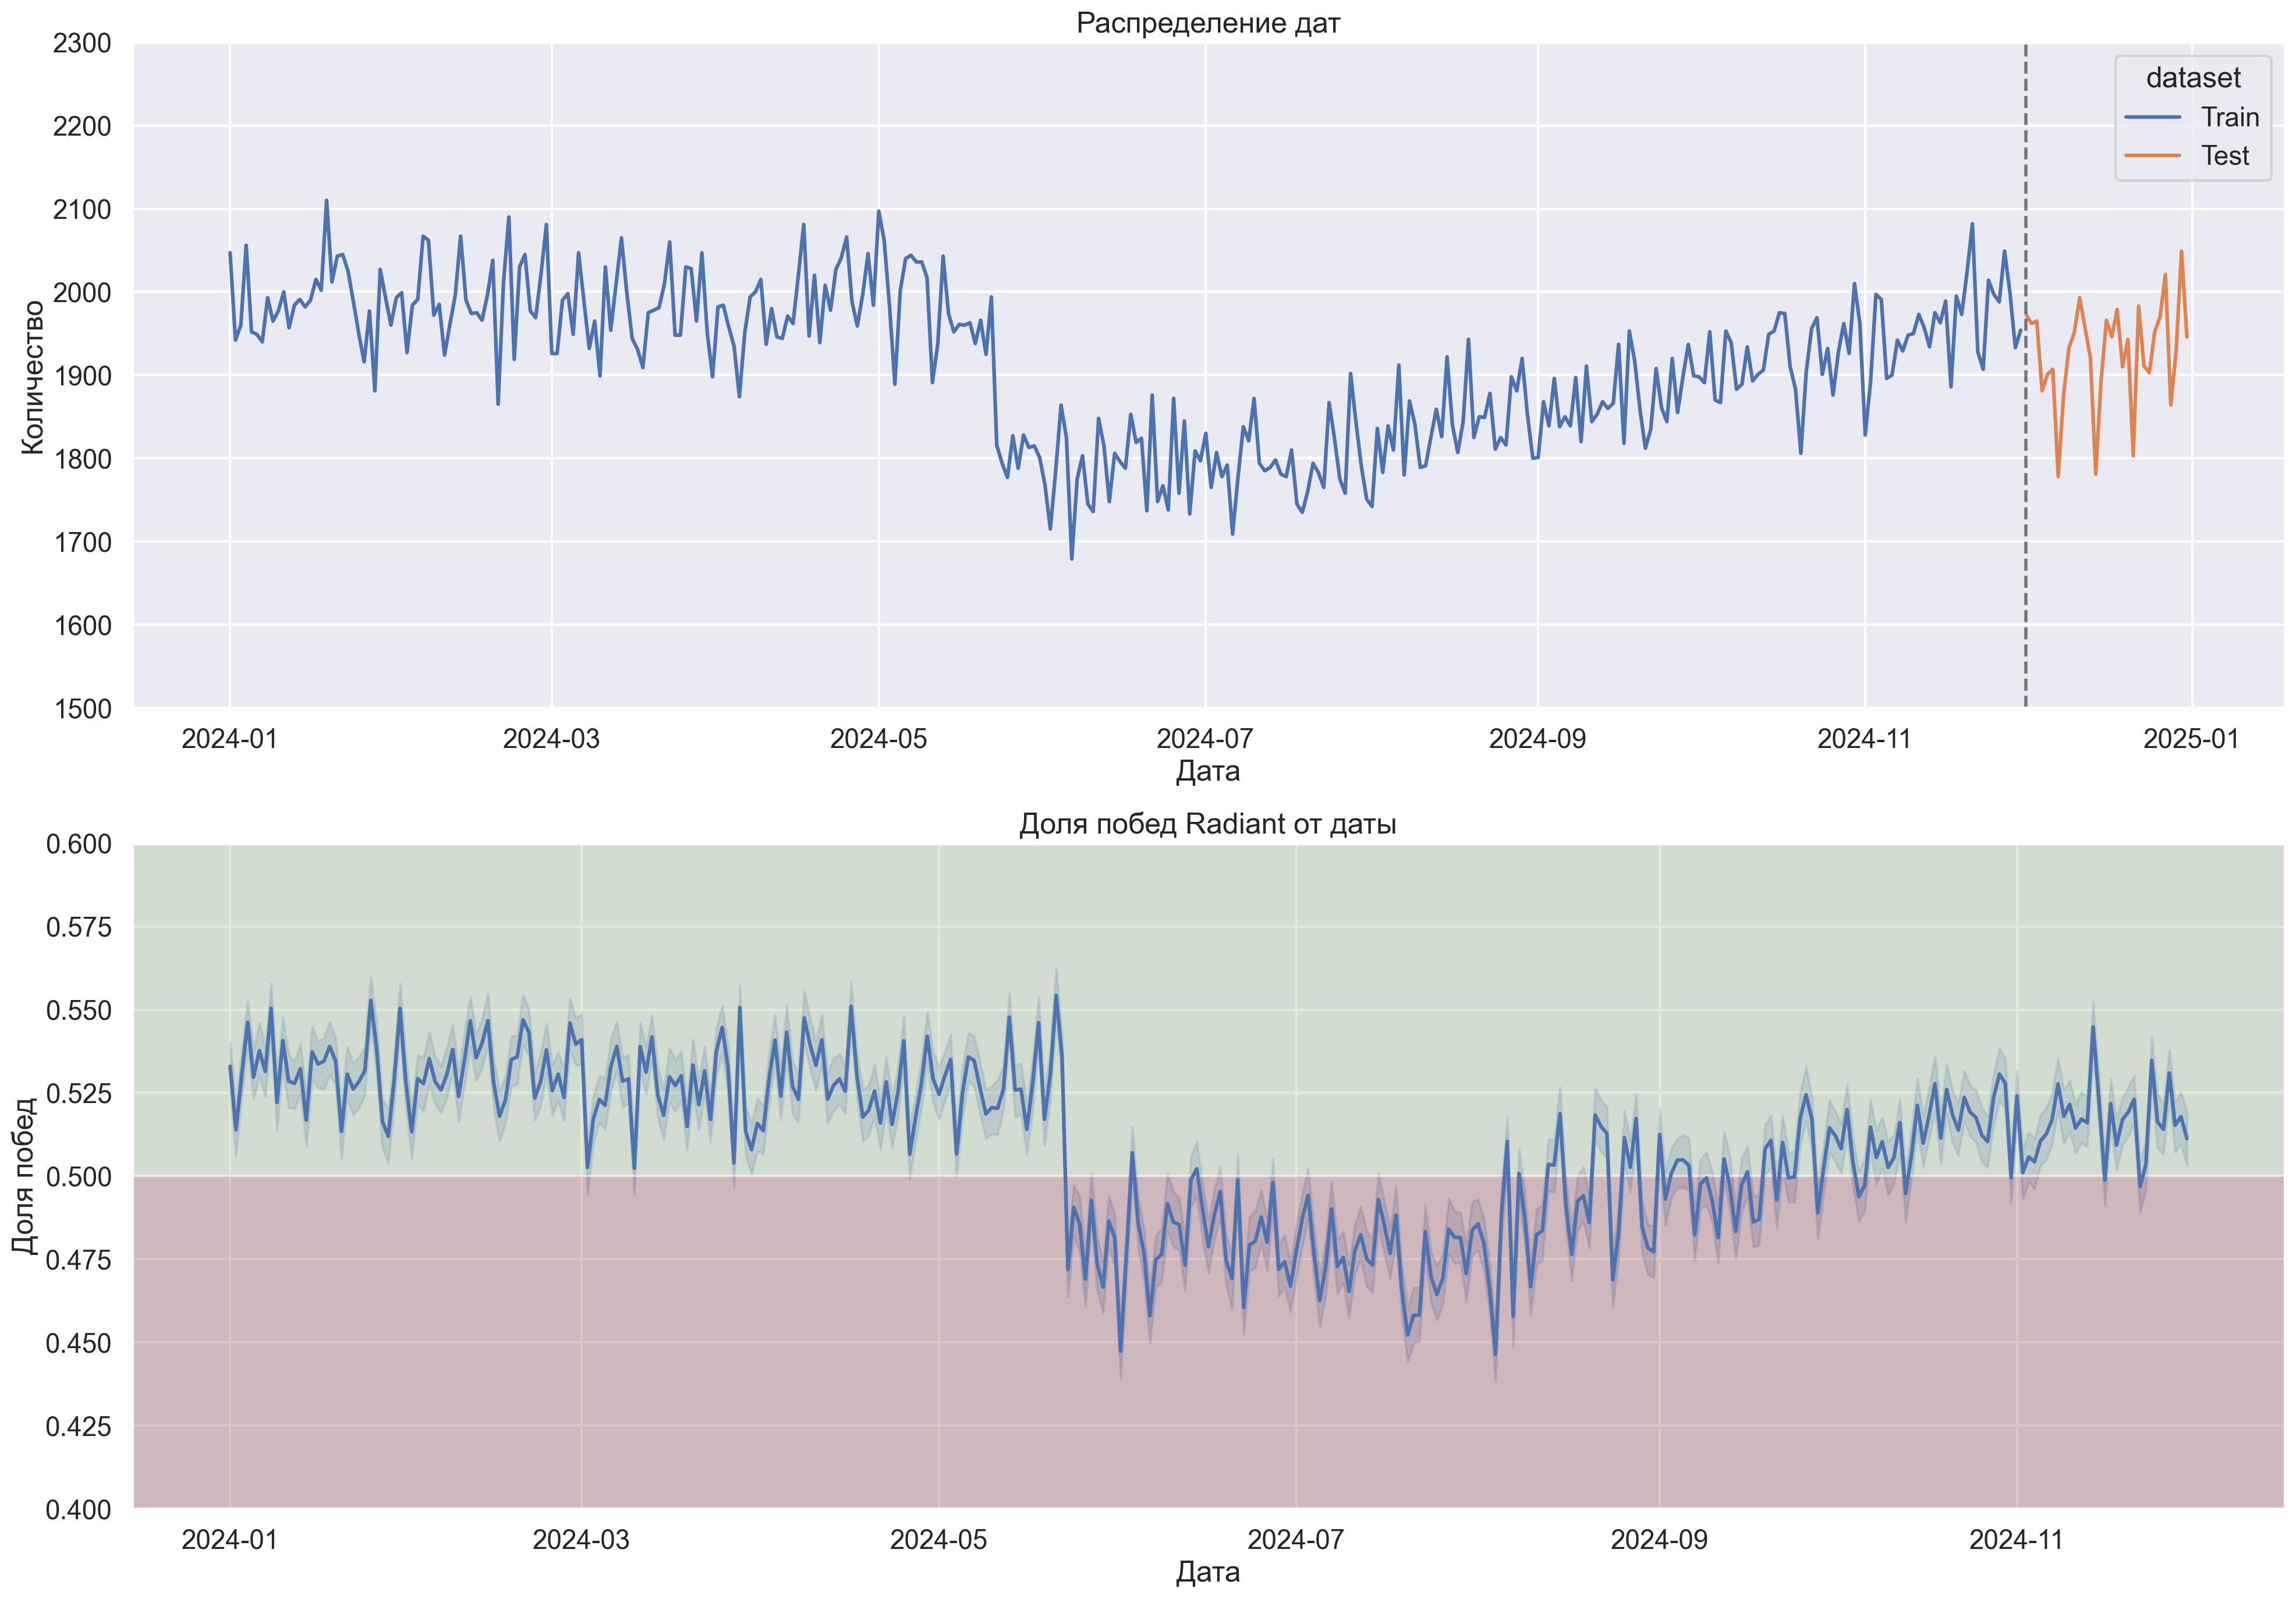

Диапазон в тренировочных данных: 2024-01-01 00:00:00 2024-11-30 00:00:00
Диапазон в тестовых данных: 2024-12-01 00:00:00 2024-12-31 00:00:00


In [241]:
tmp = (df_matches_all.groupby(['date', 'dataset']).size().reset_index(name='count'))

fig, ax = plt.subplots(2, 1, figsize=(20, 14))
ax = ax.flatten()

sns.lineplot(data=tmp, x='date', y='count', hue='dataset', ax=ax[0])

ax[0].set_title('Распределение дат')
ax[0].set_xlabel('Дата')
ax[0].set_ylabel('Количество')
ax[0].set_ylim((1500, 2300))
ax[0].axvline(x=pd.Timestamp('2024-12-01'), color='black', linestyle='--', linewidth=2, alpha=0.5)

sns.lineplot(data=matches_df_train, x='date', y='radiant_win', errorbar=('ci', 50), ax=ax[1])

ax[1].set_title('Доля побед Radiant от даты')
ax[1].set_xlabel('Дата')
ax[1].set_ylabel('Доля побед')
ax[1].set_ylim((0.4, 0.6))
ax[1].axhspan(0, 0.5, facecolor=RadiantDire[False], alpha=0.3)
ax[1].axhspan(0.5, 1, facecolor=RadiantDire[True], alpha=0.3)

plt.tight_layout()
plt.show()

# Посмотрим на диапазоны дат в тренировочных и тестовых данных
print("Диапазон в тренировочных данных:", min(matches_df_train['date']), max(matches_df_train['date']))
print("Диапазон в тестовых данных:", min(matches_df_test['date']), max(matches_df_test['date']))

#### Средний рейнтинг (`avg_mmr`)

In [242]:
bins = np.arange(0, 8050, 100)
counts1, bin_edges1 = np.histogram(matches_df_train['avg_mmr'].values, bins=bins)
counts2, bin_edges2 = np.histogram(matches_df_test['avg_mmr'].values, bins=bins)

get_color = lambda x: (
    "#49762986" if x < 770 else
    "#6949216F" if x < 1540 else
    "#1256647D" if x < 2310 else
    "#1c827471" if x < 3080 else
    "#8d1c3a7a" if x < 3850 else
    "#6f3b836e" if x < 4620 else
    "#4f5b936c" if x < 5620 else
    "#a63c186e"
)

colors = [get_color(x) for x in bin_edges1[:-1]]

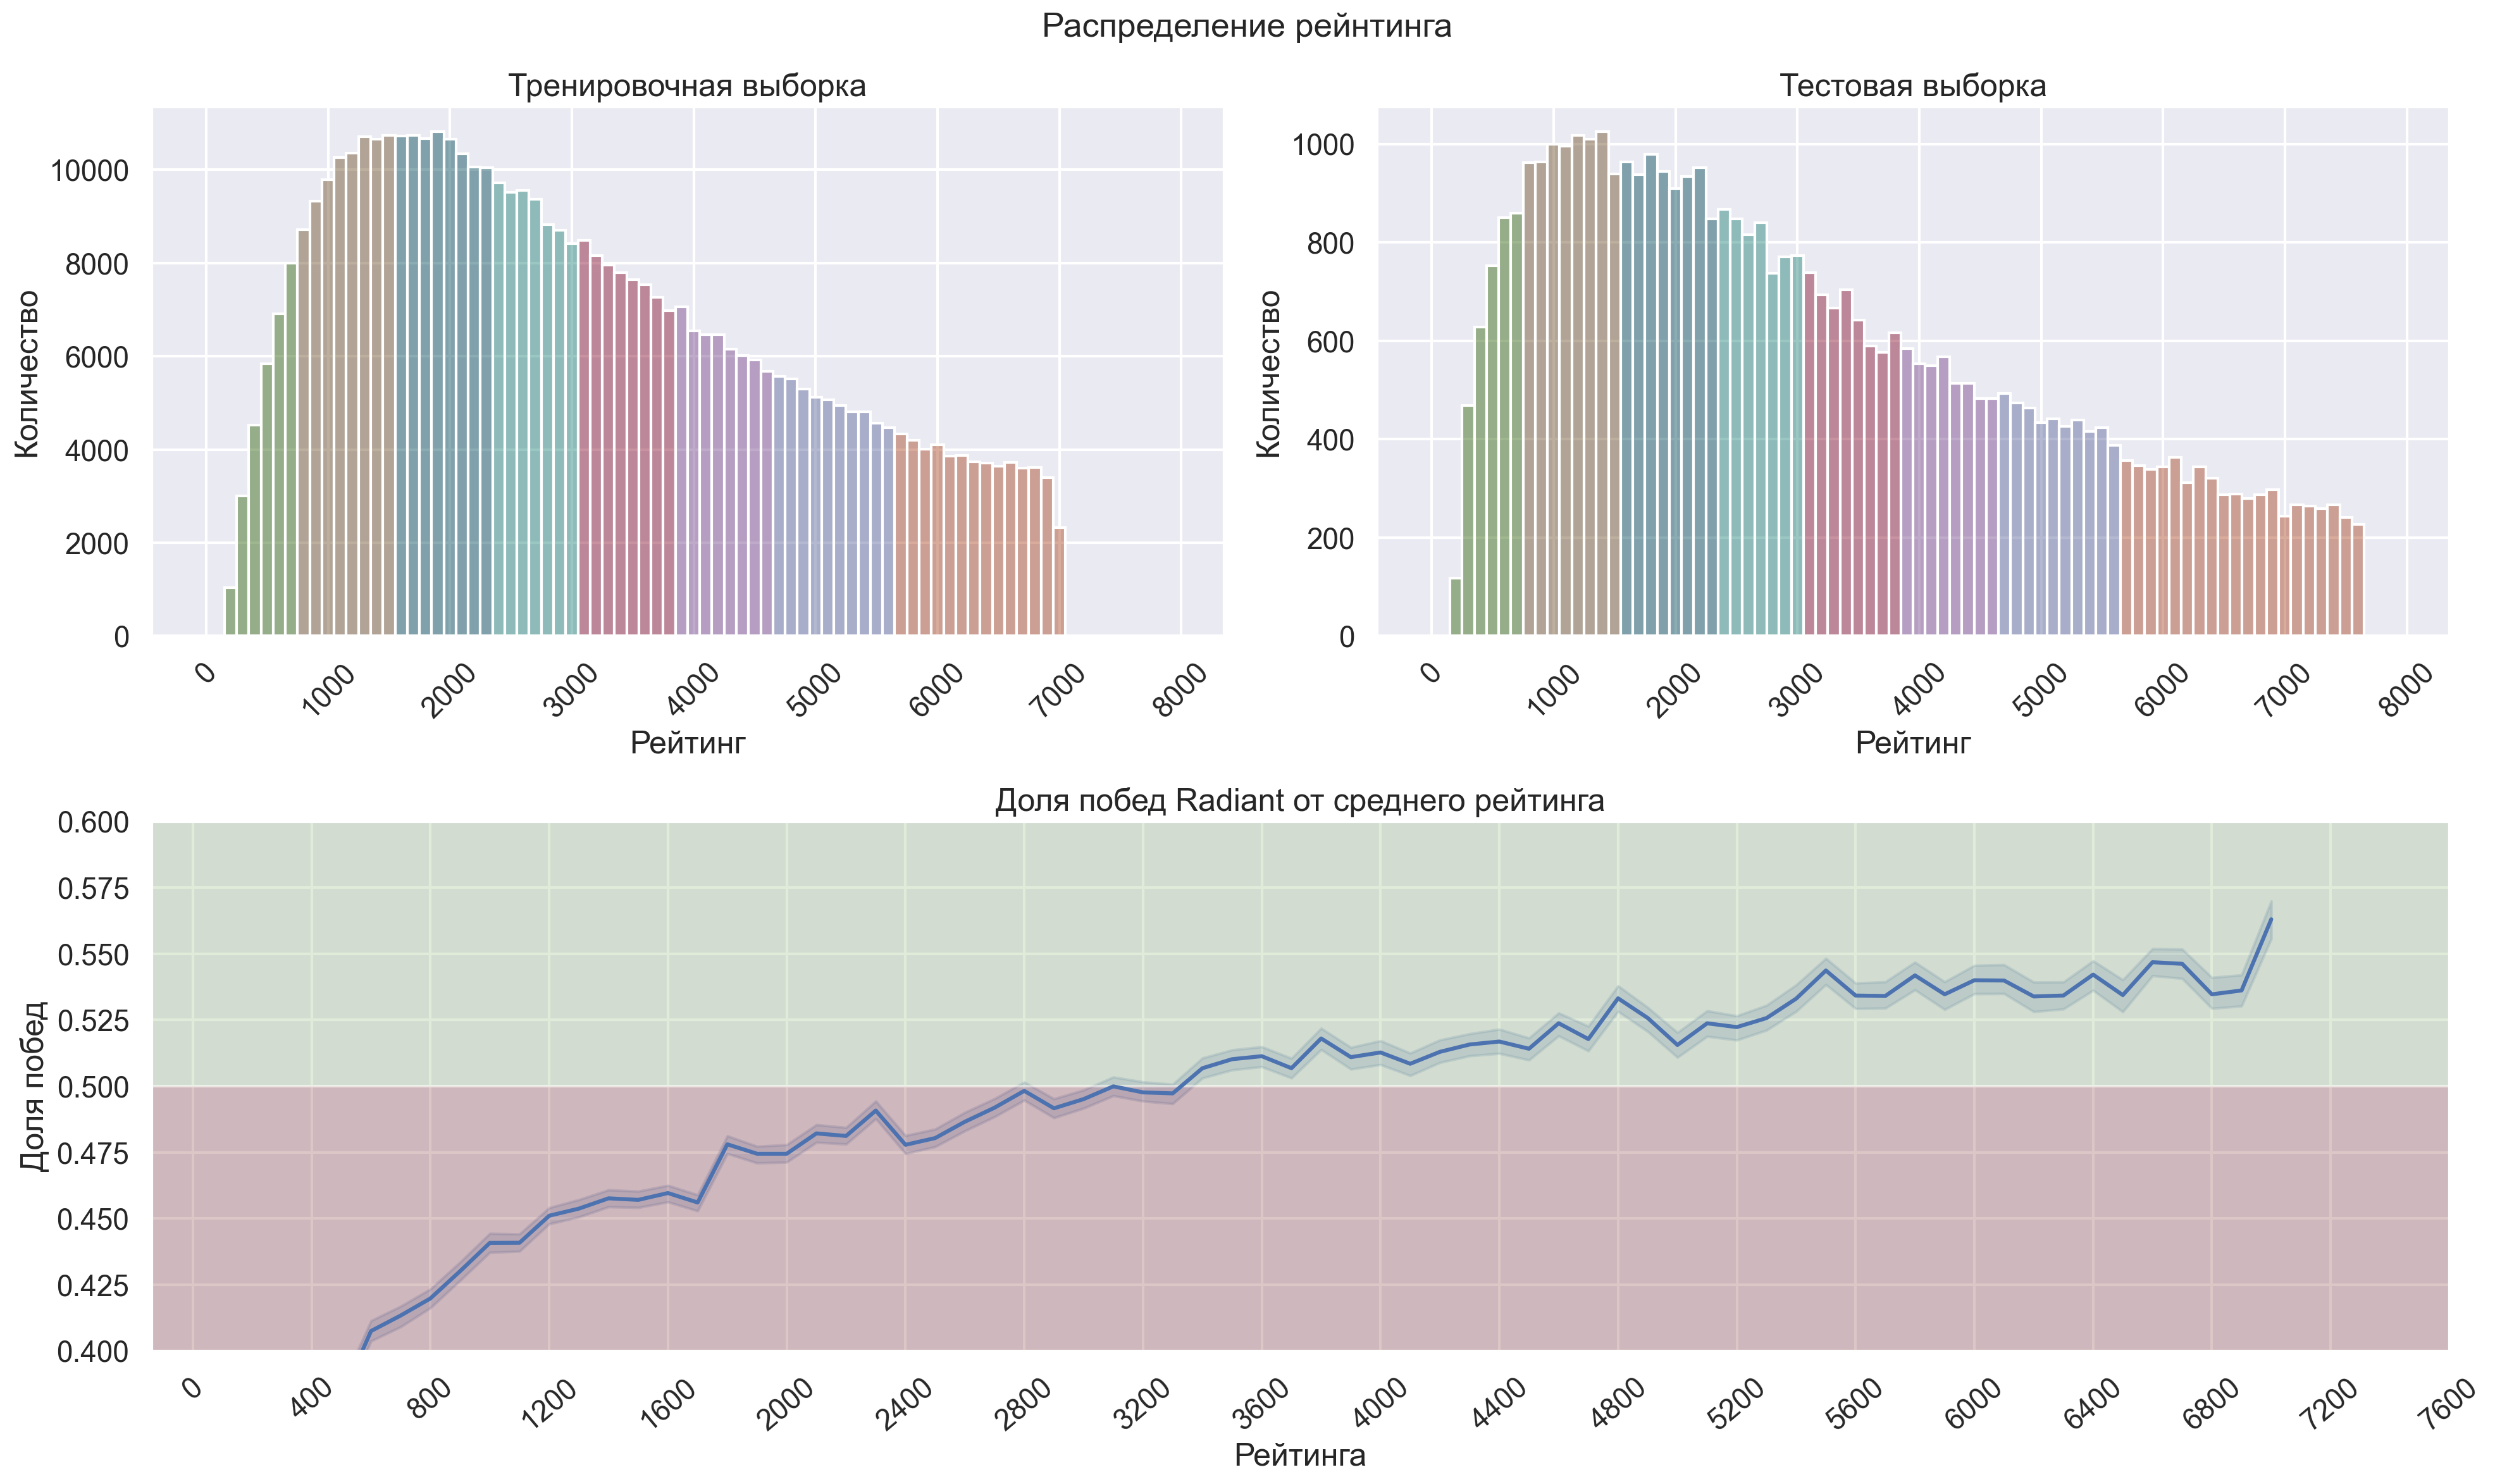

In [243]:
bins = np.arange(0, 8050, 100)

temp = matches_df_train['radiant_win'].to_frame()

temp['mmr_bin'] = pd.cut(matches_df_train['avg_mmr'], bins=bins, labels = [str(i) for i in range(00, 8000, 100)])

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2)

ax = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, :])]

plt.suptitle('Распределение рейнтинга')

ax[0].bar(bin_edges1[:-1], counts1, width=np.diff(bin_edges1), color=colors)
ax[1].bar(bin_edges2[:-1], counts2, width=np.diff(bin_edges2), color=colors)

ax[0].set_title('Тренировочная выборка')
ax[0].set_xlabel('Рейтинг')
ax[0].set_ylabel('Количество')
ax[0].tick_params(axis='x', rotation=45)

ax[1].set_title('Тестовая выборка')
ax[1].set_xlabel('Рейтинг')
ax[1].set_ylabel('Количество')
ax[1].tick_params(axis='x', rotation=45)

sns.lineplot(data=temp, x='mmr_bin', y='radiant_win', ax=ax[2], errorbar=('ci', 50))

ax[2].set_title('Доля побед Radiant от среднего рейтинга')
ax[2].set_xlabel('Рейтинга')
ax[2].set_ylabel('Доля побед')
ax[2].set_ylim(0.4, 0.6)

ax[2].axhspan(0, 0.5, facecolor=RadiantDire[False], alpha=0.3)
ax[2].axhspan(0.5, 1, facecolor=RadiantDire[True], alpha=0.3)

ax[2].set_xticks(ax[2].get_xticks()[::4])
ax[2].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()

### Распределение остальных признаков и очистка тренировочных данных от выбросов

#### Средний рейнтинг


Вновь построим графикик распределения среднего ммр и попробуем сделать распределение более похожим на нормальное

In [244]:
bins = np.arange(0, 8050, 100)
counts1, bin_edges1 = np.histogram(matches_df_train['avg_mmr'].values, bins=bins)
counts2, bin_edges2 = np.histogram(matches_df_test['avg_mmr'].values, bins=bins)

get_color = lambda x: (
    "#49762986" if x < 770 else
    "#6949216F" if x < 1540 else
    "#1256647D" if x < 2310 else
    "#1c827471" if x < 3080 else
    "#8d1c3a7a" if x < 3850 else
    "#6f3b836e" if x < 4620 else
    "#4f5b936c" if x < 5620 else
    "#a63c186e"
)

colors = [get_color(x) for x in bin_edges1[:-1]]

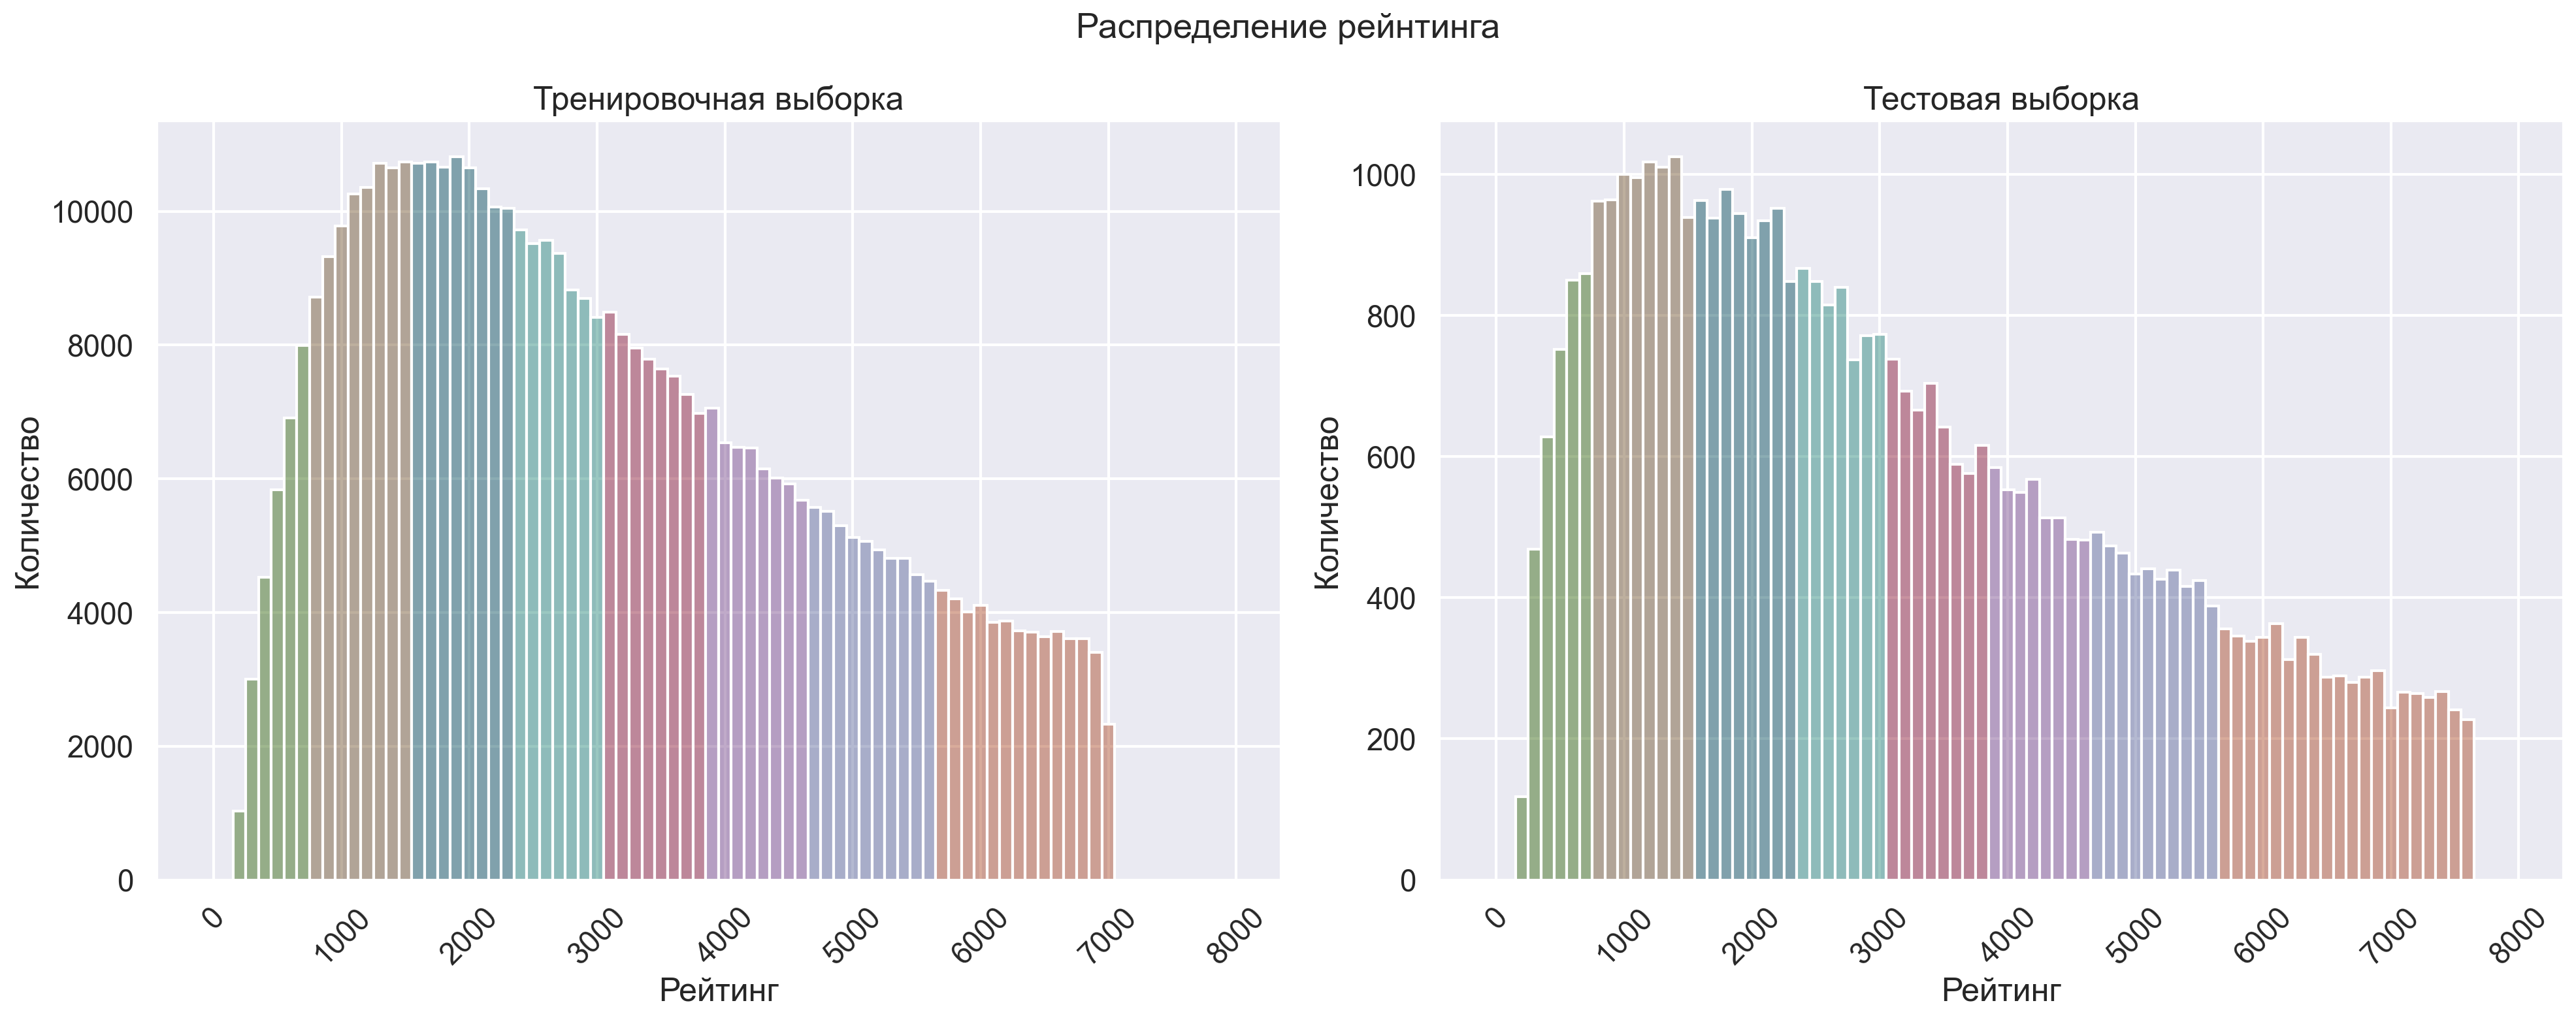

In [245]:
bins = np.arange(0, 8050, 100)

temp = matches_df_train['radiant_win'].to_frame()

temp['mmr_bin'] = pd.cut(matches_df_train['avg_mmr'], bins=bins, labels = [str(i) for i in range(00, 8000, 100)])

fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(1, 2)

ax = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]

plt.suptitle('Распределение рейнтинга')

ax[0].bar(bin_edges1[:-1], counts1, width=np.diff(bin_edges1), color=colors)
ax[1].bar(bin_edges2[:-1], counts2, width=np.diff(bin_edges2), color=colors)

ax[0].set_title('Тренировочная выборка')
ax[0].set_xlabel('Рейтинг')
ax[0].set_ylabel('Количество')
ax[0].tick_params(axis='x', rotation=45)

ax[1].set_title('Тестовая выборка')
ax[1].set_xlabel('Рейтинг')
ax[1].set_ylabel('Количество')
ax[1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

Порробуем применить логарифм к среднему MMR, т.к изначально распределение похоже на логнормальное, но с границой в 7500 MMR

In [246]:
matches_df_train['avg_mmr'] = np.log(matches_df_train['avg_mmr'])
matches_df_test['avg_mmr'] = np.log(matches_df_test['avg_mmr'])

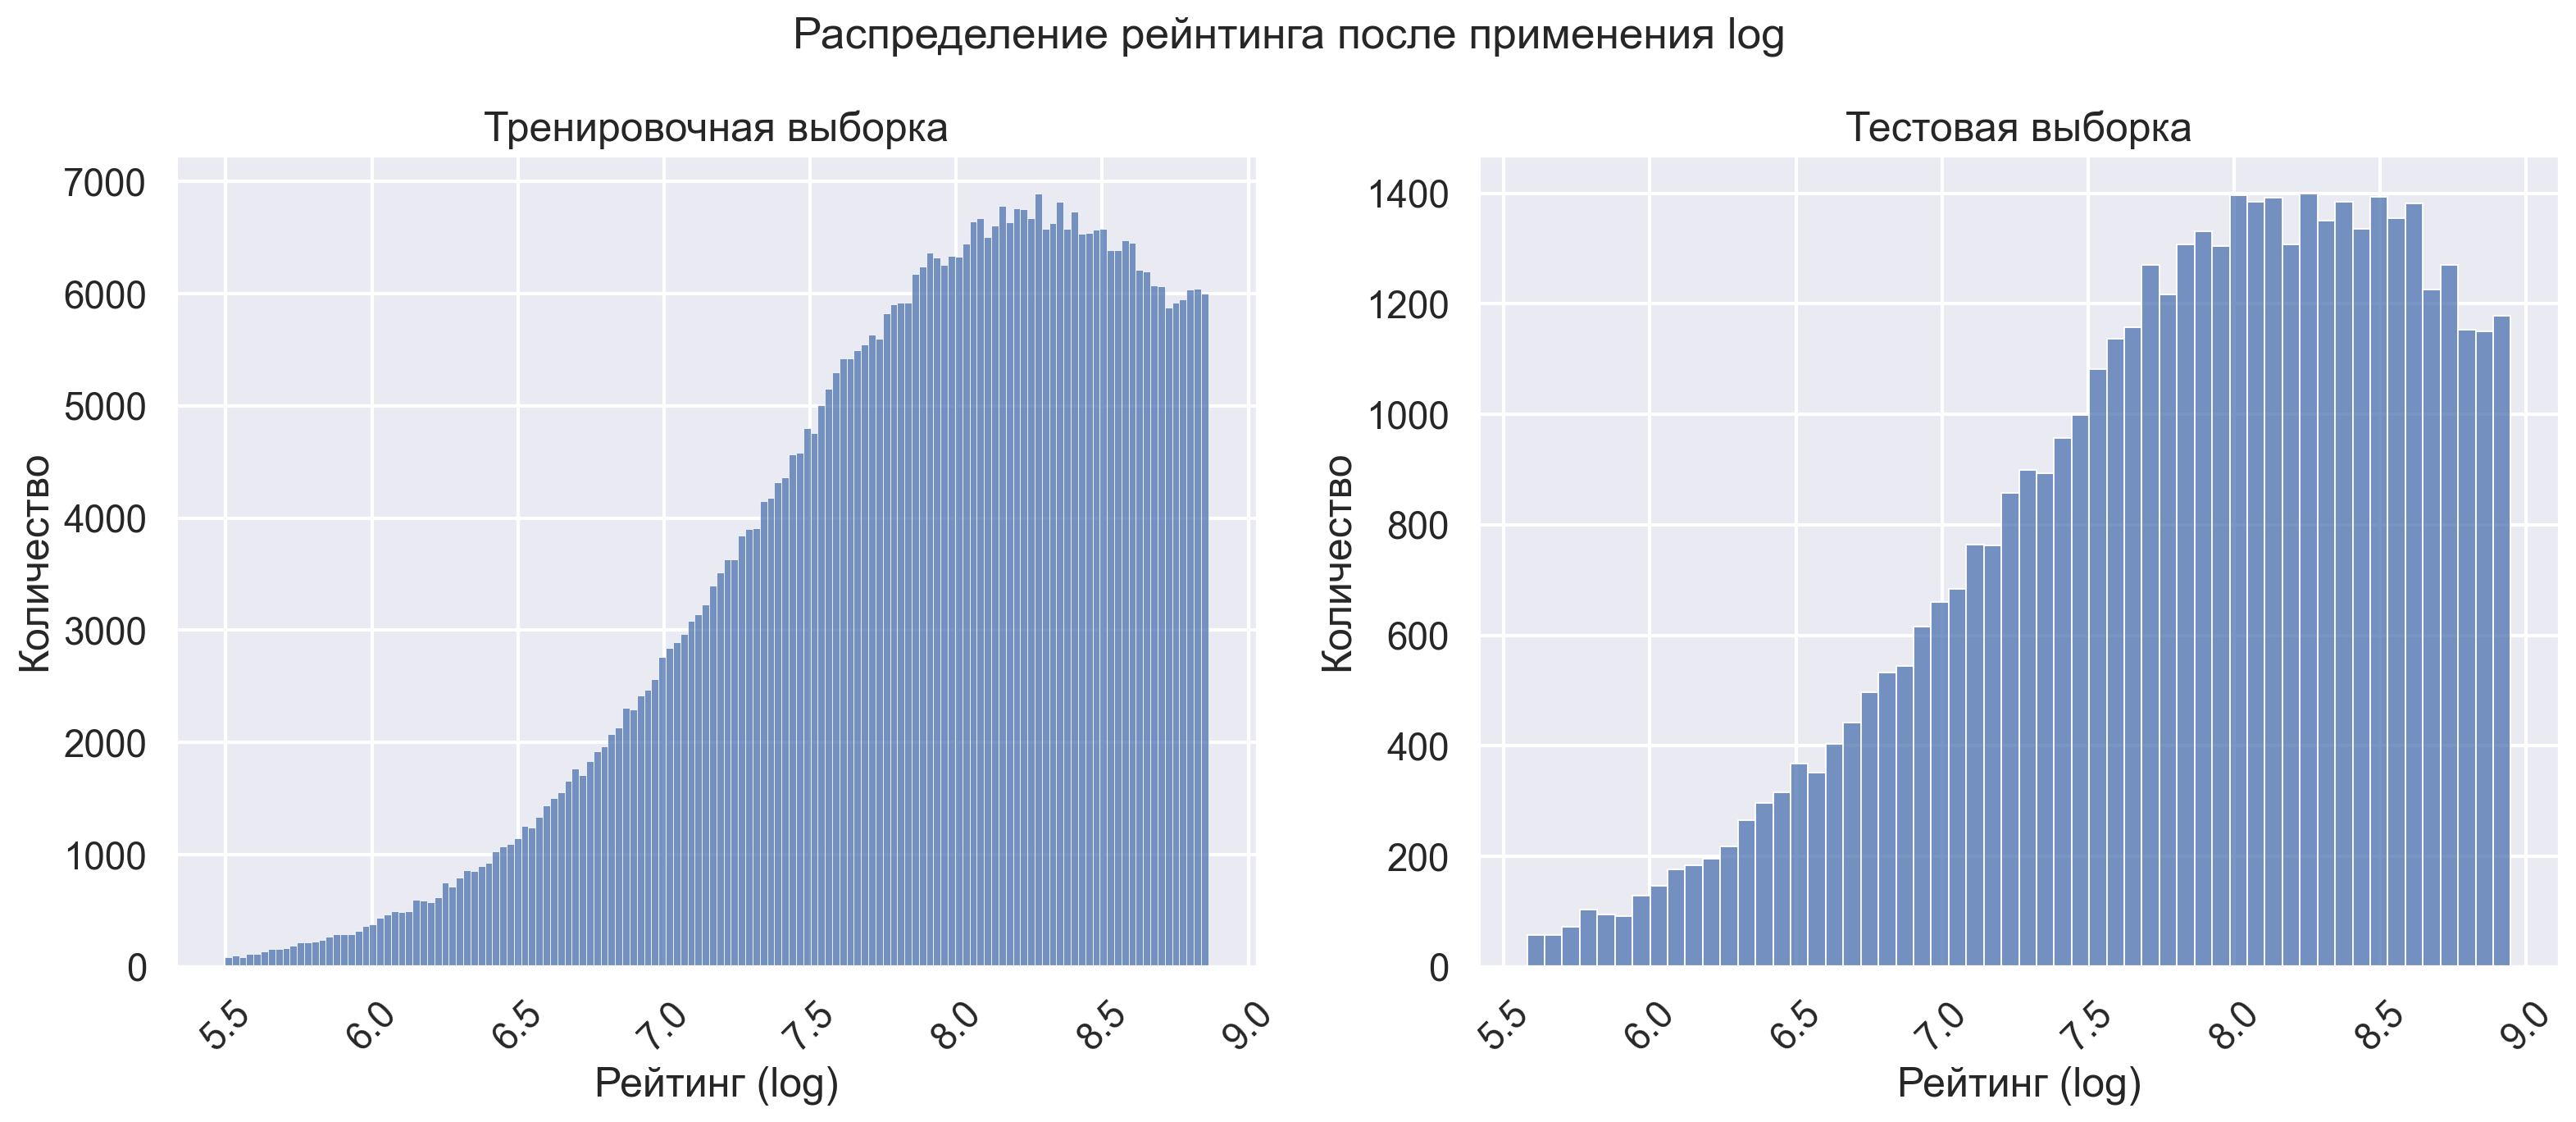

In [247]:
fig, ax = plt.subplots(1, 2)
ax = ax.flatten()

plt.suptitle("Распределение рейнтинга после применения log")

sns.histplot(data=matches_df_train, x='avg_mmr', ax=ax[0])
sns.histplot(data=matches_df_test, x='avg_mmr', ax=ax[1])

ax[0].set_title('Тренировочная выборка')
ax[0].set_xlabel('Рейтинг (log)')
ax[0].set_ylabel('Количество')
ax[0].tick_params(axis='x', rotation=45)

ax[1].set_title('Тестовая выборка')
ax[1].set_xlabel('Рейтинг (log)')
ax[1].set_ylabel('Количество')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Теперь распределение действительно походит на нормальное распределение, но с ограничением чуть выше моды.

#### Длительность матча
Данный признак отсуствует в тестовых данных, т.к допускает утечку ответа, но его можно использовать для очистки от выбросов тренировочных данных

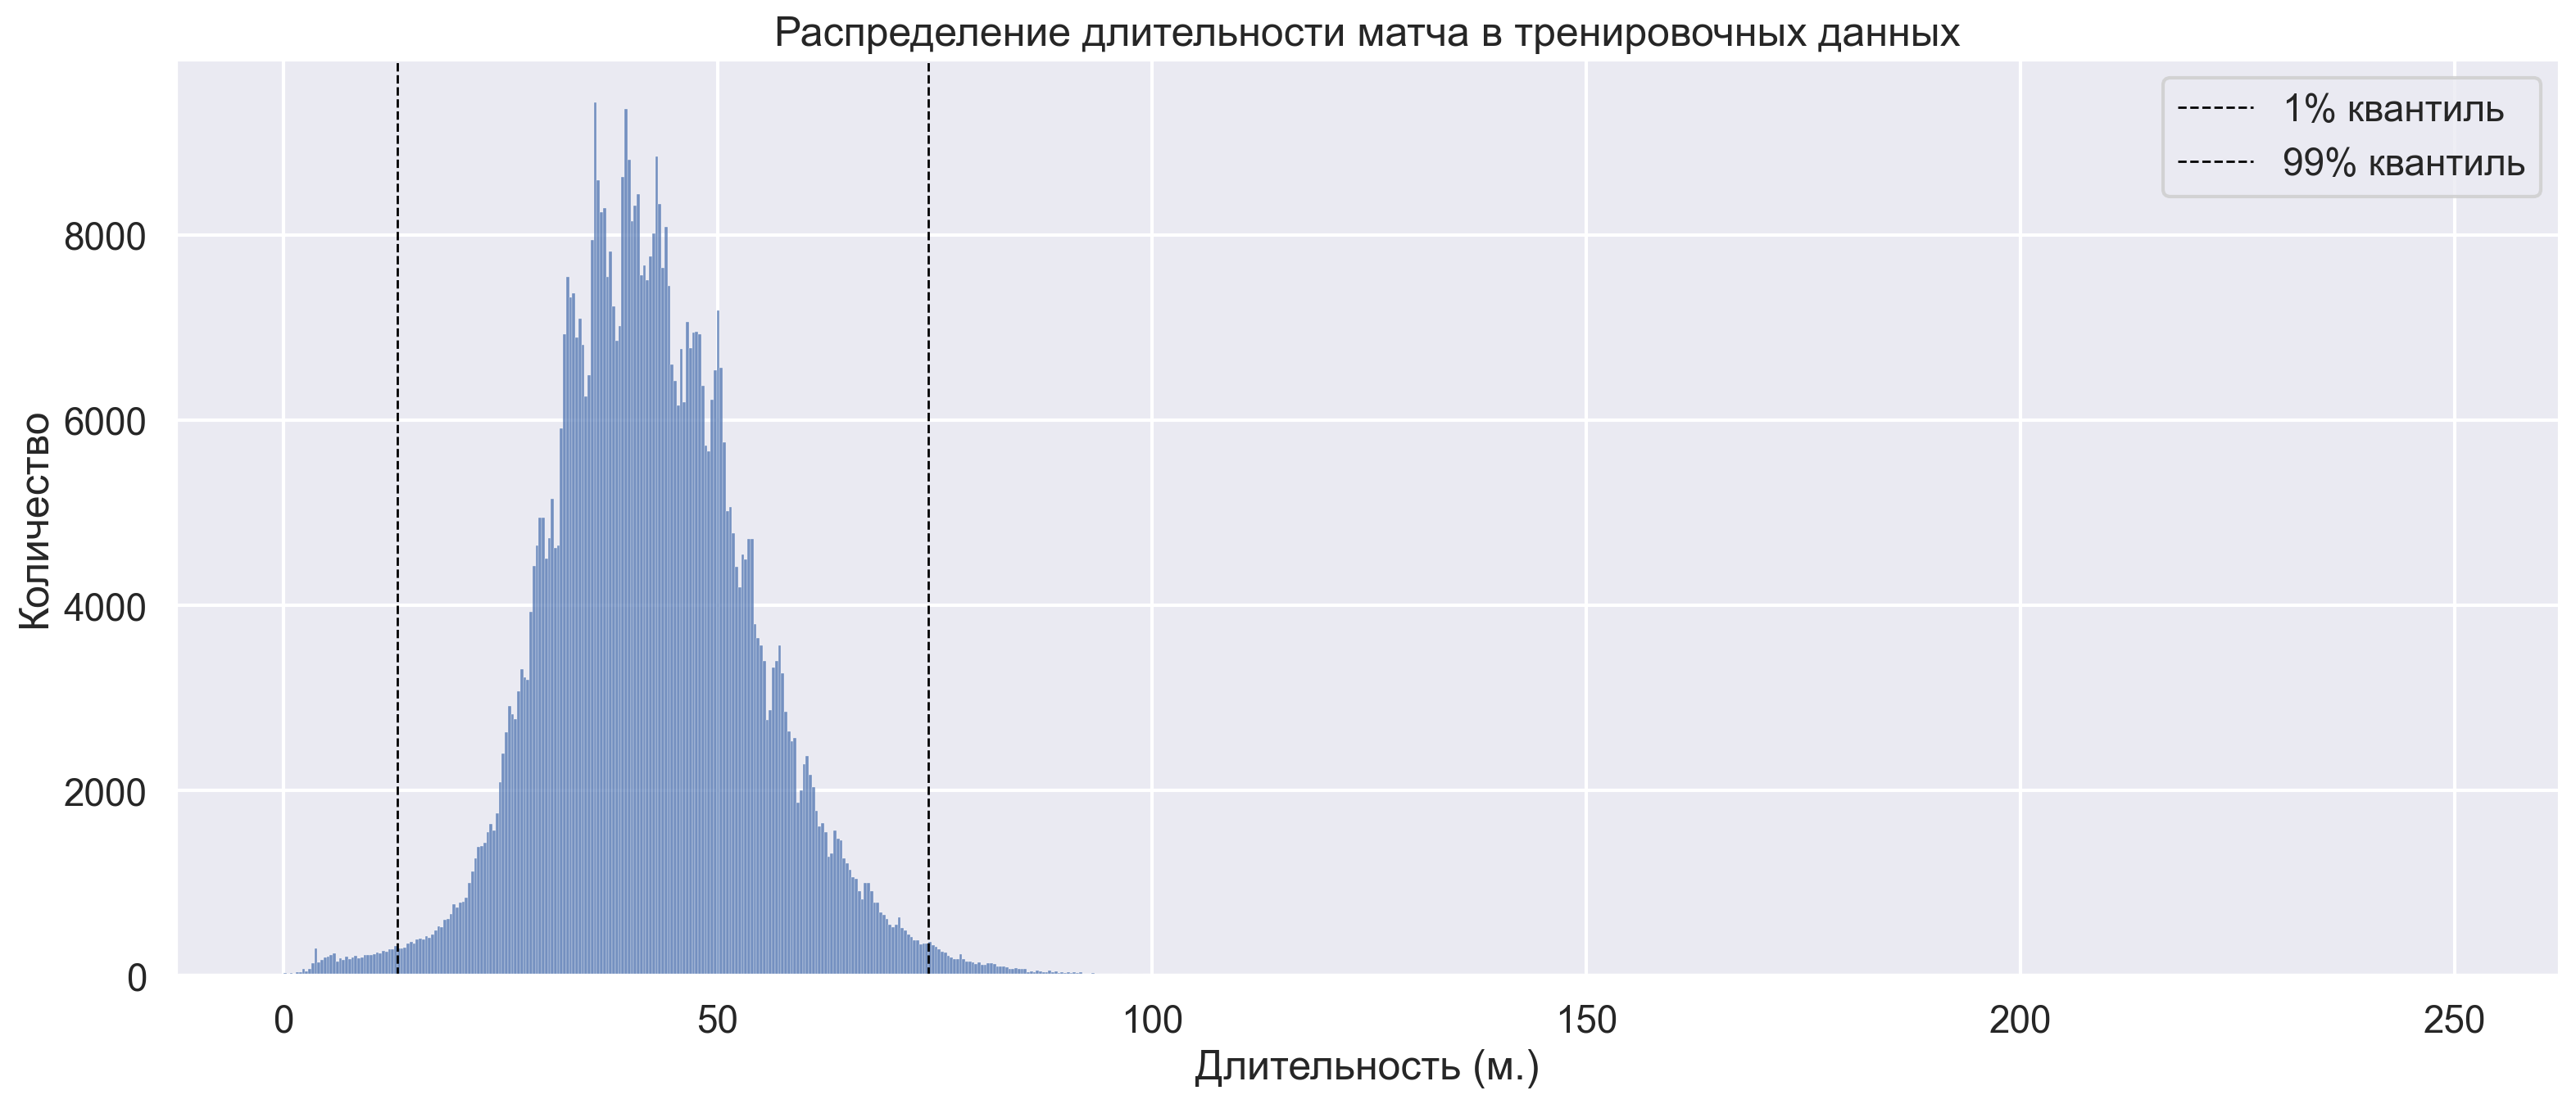

Значения квантилей: 13.066666666666666 74.25


In [248]:
fig, ax = plt.subplots()

sns.histplot(data=df_matches_all,  x=df_matches_all['duration'] / 60, ax=ax)

ax.set_title("Распределение длительности матча в тренировочных данных")
ax.set_xlabel("Длительность (м.)")
ax.set_ylabel("Количество")

q_lower, q_upper = (df_matches_all['duration'] / 60).quantile([0.01, 0.99])

ax.axvline(q_lower, color='black', linestyle='--', linewidth=1, label='1% квантиль')
ax.axvline(q_upper, color='black', linestyle='--', linewidth=1, label='99% квантиль')

plt.legend()
plt.tight_layout()
plt.show()
print("Значения квантилей:", q_lower, q_upper)

Посчитаем за выбросы матчи меньше 15 минут и больше 85, т.к первые не могут быть в тестовой выборке(матчи там длинной от 15 минут), а вторые длятся слишком долго (моё личное мнение как игрока)

In [249]:
bad_duration_mask = (matches_df_train['duration'] / 60 > 85) | (matches_df_train['duration'] / 60 < 15)
display(matches_df_train[bad_duration_mask])

matches_df_train = matches_df_train[~bad_duration_mask]

df_matches_all = pd.concat([matches_df_train, matches_df_test])


,date,region,game_mode,duration,radiant_win,avg_mmr,dataset
match_id,,,,,,,
2,2024-04-08,South Africa,2,7526,True,7.754010,Train
20,2024-07-06,Europe West,3,863,False,8.102889,Train
21,2024-02-13,Europe West,2,814,True,7.208896,Train
49,2024-01-29,Europe West,1,5593,False,7.843535,Train
87,2024-11-03,US East,4,297,False,6.544631,Train
...,...,...,...,...,...,...,...
767128,2024-01-18,SE Asia,21,272,False,NaN,Train
767195,2024-10-12,SE Asia,1,519,True,7.934299,Train
767328,2024-10-22,US East,1,5620,False,6.295635,Train


### Игроки 
Смотрим на файл игроков, чистим и добавляем в основную таблицу

In [250]:
players_df = pd.read_csv(raw_data_path / "player_df.csv")

players_df.head()

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
0,130,10111871,5,3.0,8.0,15.0,2971.0,55.0,3.0,291.0,390.0,7431.0,146.0,215380
1,130,43341844,3,3.0,9.0,3.0,1245.0,25.0,3.0,238.0,346.0,4187.0,34.0,185234
2,130,72157343,53,9.0,6.0,20.0,4544.0,226.0,1.0,583.0,704.0,9406.0,2375.0,573078
3,1,4294967295,17,21.0,3.0,15.0,2945.0,209.0,12.0,577.0,641.0,30957.0,1801.0,366576
4,2,54350942,19,9.0,8.0,8.0,413.0,227.0,9.0,471.0,584.0,18215.0,627.0,455795


Проверим `account_id`, там должно быть особое значение для анонимных аккаунтов и для некорректных данных.

In [251]:
display(players_df["account_id"].value_counts())

# Заметим значение -1, именно оно отвечает за некоректные матчи, дропнем матчи с участием таких id
players_df = players_df[~(players_df['account_id'] == -1)]

# Также оставим только те строки, айди матчей которых есть в train и test
players_df = players_df[players_df['match_id'].isin(df_matches_all.index)]


account_id
 4294967295    2795673
-1               27267
 37619671          801
 84244723          763
 87266522          761
                ...   
 75278128            1
 198435393           1
 156405264           1
 103714666           1
 114328757           1
Name: count, Length: 974931, dtype: int64

Далее необходимо убрать match_id, в которых с игроками что-то не так, а именно:
- Игроки на герое с `hero_id=0`
- Игроки с пропуском в `hero_id`
- Игроки, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь анонимным id
- Матчи, в которых не ровно 5 игроков сил Тьмы и сил Света

In [252]:
bad_matches = set()

bad_matches |= set(players_df.loc[players_df['hero_id'] == 0, 'match_id'])
bad_matches |= set(players_df.loc[players_df['hero_id'].isna(), 'match_id'])

dup_players = (players_df.loc[players_df['account_id'] != 4294967295].groupby(['match_id', 'account_id']).size())
bad_matches |= set(dup_players[dup_players > 1].index.get_level_values(0))

players_df['isRadiant'] = players_df['player_slot'] <= 4

team_counts = players_df.groupby(['match_id', 'isRadiant']).size()
bad_matches |= set(team_counts[team_counts != 5].index.get_level_values(0))

hero_counts = players_df.groupby('match_id')['hero_id'].nunique()
bad_matches |= set(hero_counts[hero_counts != 10].index)

players_df = players_df[~players_df['match_id'].isin(bad_matches)]

In [253]:
# Удалим данные матчи из train
matches_df_train = matches_df_train.loc[~matches_df_train.index.isin(bad_matches)]

df_matches_all = pd.concat([matches_df_train, matches_df_test])
# Удалили и информацию о 500 играх в тесте, но кол-во терпимое, поэтому просто заполним потом вручную
matches_df_test.loc[matches_df_test.index.isin(bad_matches)]

,date,region,game_mode,avg_mmr,dataset
match_id,,,,,
1199,2024-12-18,Middle East,22,NaN,Test
2763,2024-12-18,Europe West,1,6.416405,Test
8066,2024-12-07,Europe West,22,NaN,Test
10925,2024-12-13,Europe West,22,NaN,Test
12370,2024-12-31,South America,1,7.930026,Test
...,...,...,...,...,...
761204,2024-12-13,China,1,7.447751,Test
762333,2024-12-14,Middle East,1,NaN,Test
762641,2024-12-12,Europe West,22,6.827304,Test


#### Посмотрим статистики игроков, удалим игроков с странной статистикой, а также заменим выбросы в матче на средние показатели игрока

In [254]:
player_stats = (
    players_df
    .groupby('account_id')
    .agg(
        matches=('match_id', 'count'),
        mean_kills=('kills', 'mean'),
        mean_deaths=('deaths', 'mean'),
        mean_assists=('assists', 'mean'),
        mean_gold=('gold', 'mean'),
        mean_last_hits=('last_hits', 'mean'),
        mean_denies=('denies', 'mean'),
        mean_gpm=('gold_per_min', 'mean'),
        mean_xpm=('xp_per_min', 'mean'),
        mean_hero_damage=('hero_damage', 'mean'),
        mean_tower_damage=('tower_damage', 'mean')
    )
    .reset_index()
)

player_stats = player_stats.set_index('account_id')

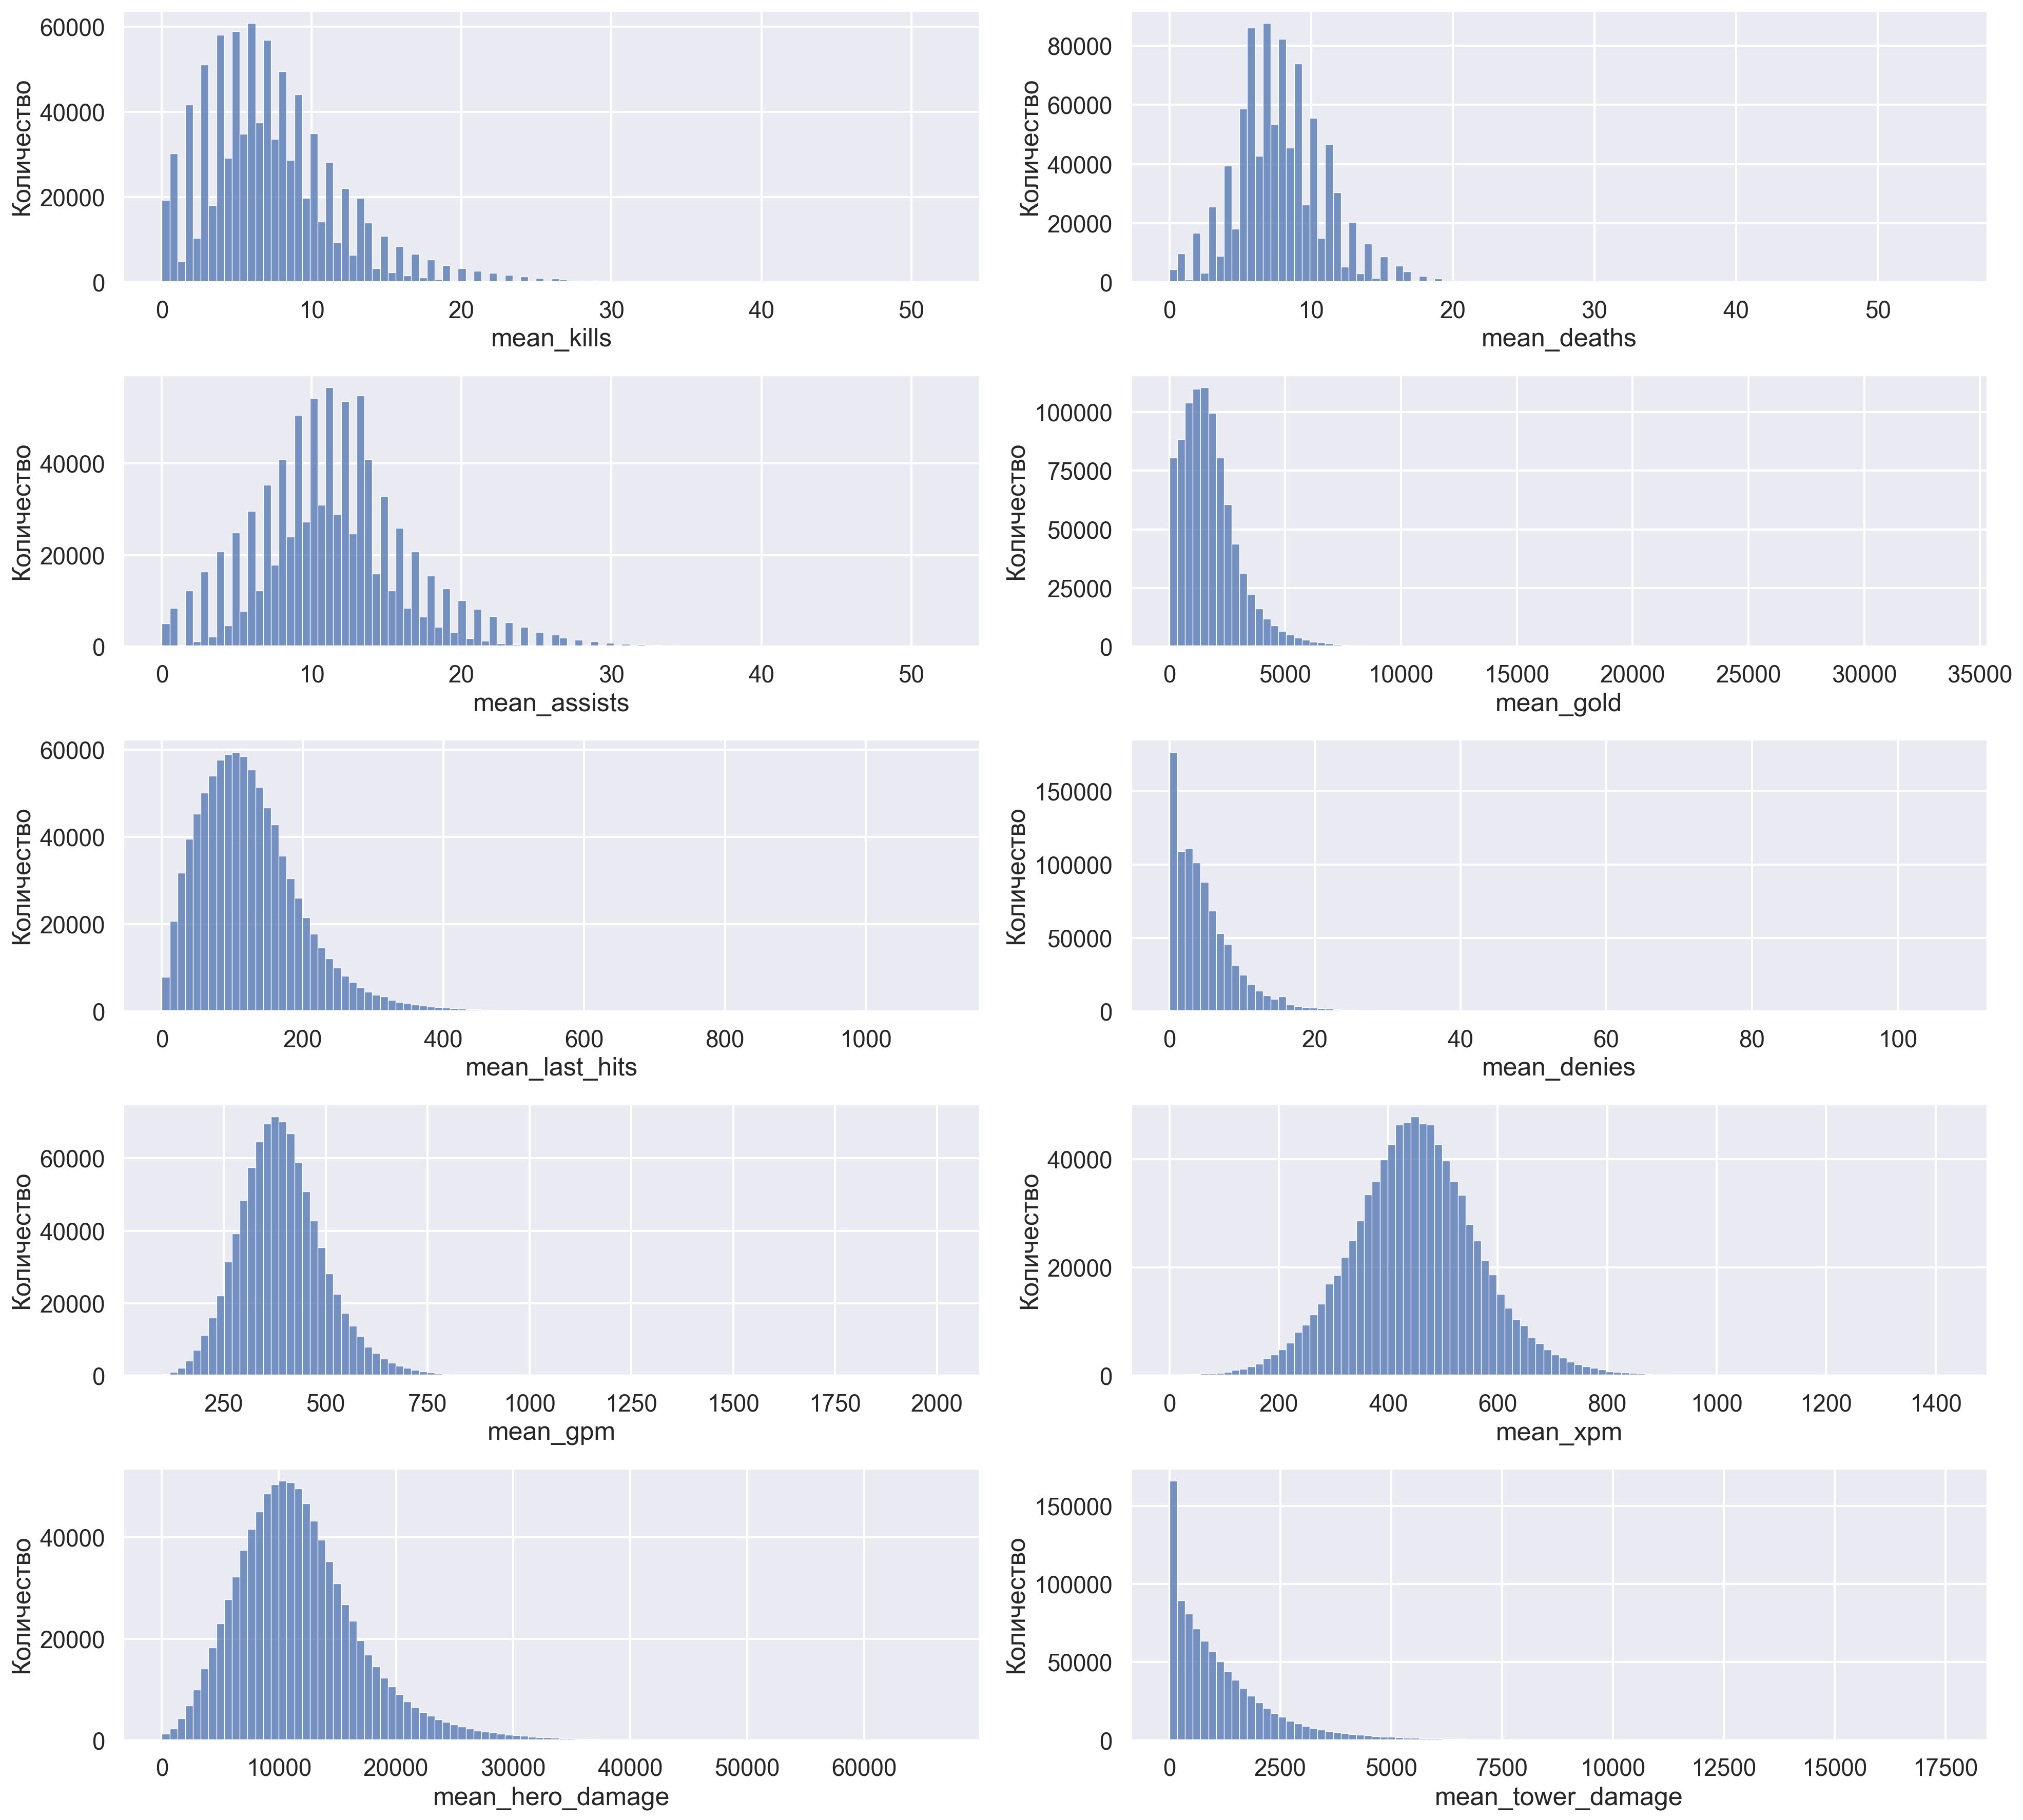

In [255]:
columns_index = dict(enumerate(player_stats.columns[1:]))

fig, ax = plt.subplots(5, 2, figsize = (20, 18))
ax = ax.flatten()

for i in range(10):
    sns.histplot(data=player_stats, x=columns_index[i], bins=100, ax=ax[i])
    ax[i].set_ylabel("Количество")

plt.tight_layout()
plt.show()

In [256]:
player_stats = player_stats[~(player_stats['mean_deaths'] > 22)]
player_stats = player_stats[~(player_stats['mean_kills'] > 40)]
player_stats = player_stats[~(player_stats['mean_gpm'] > 1100)]
player_stats = player_stats[~(player_stats['mean_xpm'] > 1000)]
player_stats = player_stats[~(player_stats['mean_hero_damage'] > 55000)]
player_stats = player_stats[~(player_stats['mean_tower_damage'] > 12500)]

In [257]:
match_ids = players_df.loc[
    players_df['account_id'].isin(player_stats.index),
    'match_id'
].unique()

matches_df_train = matches_df_train.loc[matches_df_train.index.intersection(match_ids)]

In [259]:
clean_data_path = PROJECT_ROOT / "data" / "clean"
matches_df_train.to_csv(clean_data_path /"matches_df_train.csv")
matches_df_test.to_csv(clean_data_path / "matches_df_test.csv")
players_df.to_csv(clean_data_path / "players_df.csv")
player_stats.to_csv(clean_data_path / "player_stats.csv")